In [1]:
print("Check_Python")

Check_Python


In [2]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [3]:
print(tf.__version__)
print(tf.config.list_physical_devices())

2.20.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [4]:
PROJECT_ROOT = Path("..") 
DATA_DIR = PROJECT_ROOT / "data" / "raw"

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR   = DATA_DIR / "val"
TEST_DIR  = DATA_DIR / "test"

TRAIN_DIR, VAL_DIR, TEST_DIR

(WindowsPath('../data/raw/train'),
 WindowsPath('../data/raw/val'),
 WindowsPath('../data/raw/test'))

In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
COLOR_MODE = "grayscale"

In [6]:
#lighter augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

We aren't using advanced data augmentation because it will risk the data. problems:-
- large data
- brightness and contrast matters

In [7]:
val_test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

In [8]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode=COLOR_MODE,
    class_mode="binary"
)

Found 5216 images belonging to 2 classes.


In [9]:
val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode=COLOR_MODE,
    class_mode="binary"
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode=COLOR_MODE,
    class_mode="binary",
    shuffle=False
)

Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [10]:
#Handling class imbalance
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_generator.classes)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_generator.classes
)

class_weights = dict(zip(classes, class_weights))
class_weights

{np.int32(0): np.float64(1.9448173005219984),
 np.int32(1): np.float64(0.6730322580645162)}

The solution we used: Class Weights
* If a class has fewer images → its mistakes are more costly
* If a class has many images → its mistakes cost less

In [12]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

In [13]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [14]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_model.h5",
        monitor="val_loss",
        save_best_only=True
    )
]

In [15]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.6709 - auc: 0.7653 - loss: 0.6054 - precision: 0.8720 - recall: 0.6466

163/163 ━━━━━━━━━━━━━━━━━━━━ 100s 593ms/step - accuracy: 0.7995 - auc: 0.8995 - loss: 0.4134 - precision: 0.9348 - recall: 0.7848 - val_accuracy: 0.9375 - val_auc: 0.9375 - val_loss: 0.3287 - val_precision: 0.8889 - val_recall: 1.0000
Epoch 2/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 81s 498ms/step - accuracy: 0.9103 - auc: 0.9715 - loss: 0.2145 - precision: 0.9707 - recall: 0.9066 - val_accuracy: 0.8750 - val_auc: 0.9688 - val_loss: 0.4221 - val_precision: 0.8000 - val_recall: 1.0000
Epoch 3/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 80s 491ms/step - accuracy: 0.9260 - auc: 0.9768 - loss: 0.1918 - precision: 0.9786 - recall: 0.9205 - val_accuracy: 0.6250 - val_auc: 0.9688 - val_loss: 0.6453 - val_precision: 0.5714 - val_recall: 1.0000
Epoch 4/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 81s 498ms/step - accuracy: 0.9375 - auc: 0.9838 - loss: 0.1586 - precision: 0.9805 - recall: 0.9345 - val_accuracy: 0.7500 - val_auc: 0.9688 - val_loss: 0.6194 - val_precision: 0.6667 - val_recall: 1.0000
Epoch 5/25
163/163 ━━━━━━━━━━━

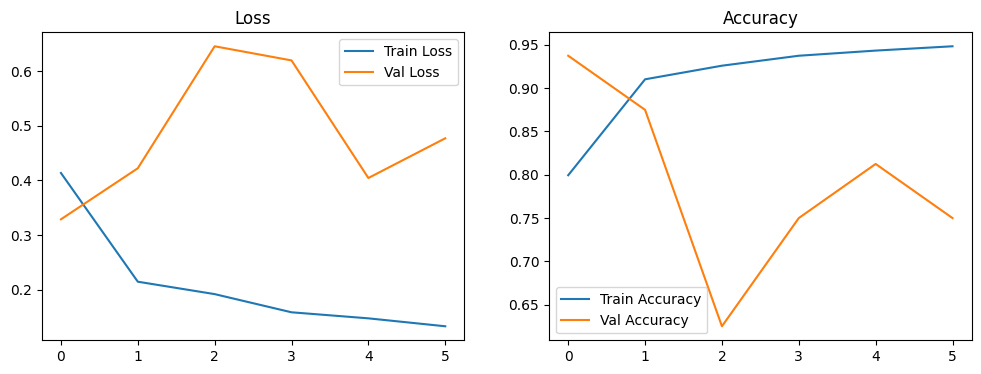

In [16]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy")

plt.show()